In [28]:
import os, heapq, itertools, warnings
from datetime import date

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import gymnasium as gym
from gymnasium import spaces

from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback
from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker

import stable_baselines3, sb3_contrib

### PDE, grid and exact solution
$u_t + a(u)\,u_x = \alpha u_{xx}$ on $[0,1]$, $u=0$ at both walls, $u(x,0)=\sin\pi x+\tfrac12\sin2\pi x$. Here $a(u)=c$.
The exact solution is only used to check results, never by the agent.

nx = 100, nt = 1090, dx = 0.01010, dt = 4.591e-04
max |u_true - u0| at t = 0: 4.5e-07


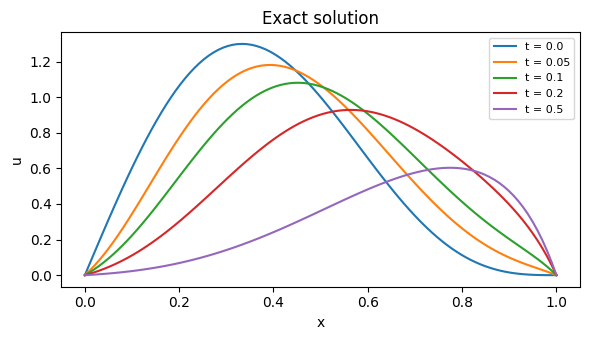

In [29]:
# ── PDE:  u_t + a(u) u_x = alpha u_xx   on [0, 1],  u = 0 at both walls ──
alpha = 0.1
c     = 1.0
a     = lambda u: c * np.ones_like(u)          # advection speed (Burgers: a(u) = u)
A_MAX = 1.0                                    # max |a(u)|, for the CFL limit
u0    = lambda x: np.sin(np.pi * x) + 0.5 * np.sin(2 * np.pi * x)

# ── Grid ──
nx, T = 100, 0.5
dx = 1.0 / (nx - 1)
nt = int(np.ceil(T / min(0.9 * dx / A_MAX, 0.45 * dx**2 / alpha))) + 1
dt = T / (nt - 1)
x_grid = np.arange(nx) * dx

# ── Exact solution: u = exp(b x - alpha b^2 t) v, b = c/(2 alpha), v solves the heat equation ──
_xq = np.linspace(0.0, 1.0, 80001)
_b  = c / (2 * alpha)
_n  = np.arange(1, 801)
_bn = np.array([2 * np.trapezoid(u0(_xq) * np.exp(-_b * _xq) * np.sin(k * np.pi * _xq), _xq) for k in _n])

def u_true(x, t):
    x = np.atleast_1d(np.asarray(x, dtype=float))
    v = (np.sin(np.pi * np.outer(x, _n)) * (_bn * np.exp(-alpha * (_n * np.pi)**2 * t))).sum(axis=1)
    return np.exp(_b * x - alpha * _b**2 * t) * v

print(f"nx = {nx}, nt = {nt}, dx = {dx:.5f}, dt = {dt:.3e}")
print(f"max |u_true - u0| at t = 0: {np.abs(u_true(x_grid, 0.0) - u0(x_grid)).max():.1e}")

fig, ax = plt.subplots(figsize=(6, 3.5))
for tk in [0.0, 0.05, 0.1, 0.2, 0.5]:
    ax.plot(x_grid, u_true(x_grid, tk), label=f"t = {tk}")
ax.set_xlabel("x"); ax.set_ylabel("u"); ax.set_title("Exact solution"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### FD baselines and the Taylor predictor
**Baselines**, each run on the full grid from the initial condition up to $z^*$:
- **FD-3**: central in space, forward Euler in time (3 points).
- **LW**: Lax–Wendroff (3 points, 2nd order).
- **FD-5**: 4th-order central in space, forward Euler (5 points). It is unstable at our $\Delta t$ ($r=\alpha\Delta t/\Delta x^2=0.45>3/8$), so it runs with $\Delta t/2$.

For each we report the error at $z^*$, the computed points in the cone below $z^*$, and the work (points × neighbours).

**Taylor predictor (thesis §2.5).** $\hat u_p=\sum_q w_q u_q$ from 5 neighbours. With $\xi=\Delta x-a\Delta t$ (the PDE substituted for $u_t$), the weights satisfy
$$\sum w=1,\qquad \sum w\,\xi=0,\qquad \sum w\left(\tfrac12\xi^2+\alpha\Delta t\right)=0 .$$
We take the min-norm solution. A stencil is **admissible** if the rows have rank 3, cond $\le10^4$ and $\|w\|_1\le2$. Which can be relaxed later.
Check: with 3 points one level down, the predictor is exactly Lax–Wendroff.

In [30]:
# ── FD baselines on the full grid, run from the initial condition up to z* ──
#   FD-3 : central in space, forward Euler in time                (3 points, 1st order in time)
#   LW   : Lax-Wendroff                                            (3 points, 2nd order)
#   FD-5 : 4th-order central in space, forward Euler, 3-point next to the walls (5 points)
#          explicit FD-5 is unstable at our dt (needs r <= 3/8), so it runs with dt/2
def fd_step(u, scheme, k):
    """One time step of size k."""
    r, ui = alpha * k / dx**2, u[1:-1]
    nu = a(ui) * k / dx
    n = u.copy()
    n[1:-1] = ui + r * (u[2:] - 2 * ui + u[:-2]) - nu / 2 * (u[2:] - u[:-2])
    if scheme == "LW":
        n[1:-1] += nu**2 / 2 * (u[2:] - 2 * ui + u[:-2])
    if scheme == "FD-5":
        v, nu = u[2:-2], a(u[2:-2]) * k / dx
        n[2:-2] = (v + r * (-u[4:] + 16 * u[3:-1] - 30 * v + 16 * u[1:-3] - u[:-4]) / 12
                     - nu * (-u[4:] + 8 * u[3:-1] - 8 * u[1:-3] + u[:-4]) / 12)
    n[0] = n[-1] = 0.0
    return n

FD_SCHEMES = {"FD-3": (1, 3), "LW": (1, 3), "FD-5": (2, 5)}   # (sub-steps per dt, neighbours per point)
_fd_cache = {}
def fd_reference(ix, it, scheme):
    """Baseline at z* = (ix, it): value, error, computed points in the cone below z*, work = points x neighbours."""
    key = (ix, it, scheme)
    if key not in _fd_cache:
        sub, n_nb = FD_SCHEMES[scheme]
        u = u_true(x_grid, 0.0)                     # same initial data the map will use
        for _ in range(it * sub):
            u = fd_step(u, scheme, dt / sub)
        err = abs(u[ix] - u_true(ix * dx, it * dt)[0])
        s = n_nb // 2                               # the cone widens by s cells per level
        n_pts = sum(min(nx - 2, ix + s * j) - max(1, ix - s * j) + 1 for j in range(it * sub))
        _fd_cache[key] = (u[ix], err, n_pts, n_pts * n_nb)
    return _fd_cache[key]

print(f"r = alpha dt/dx^2 = {alpha * dt / dx**2:.3f}")
for z in [(50, 20), (50, 100)]:
    for scheme in FD_SCHEMES:
        _, err, n_pts, work = fd_reference(*z, scheme)
        print(f"z* = {z}  {scheme:5s}: error {err:.2e}, {n_pts:5d} points, work {work:6d}")

# ── Taylor predictor: 3 rows (value, u_x, u_xx) with u_t = alpha u_xx - a u_x substituted ──
COND_MAX, W_MAX = 1e4, 2.0
def solve_weights(dxs, dts, a_loc):
    """Min-norm weights of the neighbours at offsets (dxs, dts); a_loc = local advection speed.
    None if not admissible: rank < 3, cond > COND_MAX, or ||w||_1 > W_MAX."""
    xi = dxs - a_loc * dts                                  # offset in the moving frame
    h  = max(np.abs(dxs).max(), np.sqrt(alpha * np.abs(dts).max()))
    A  = np.array([np.ones_like(dxs), xi / h, (0.5 * xi**2 + alpha * dts) / h**2])
    if np.linalg.matrix_rank(A) < 3 or np.linalg.cond(A) > COND_MAX:
        return None
    w = np.linalg.pinv(A) @ np.array([1.0, 0.0, 0.0])
    return w if np.abs(w).sum() <= W_MAX else None

r, nu = alpha * dt / dx**2, c * dt / dx
w3 = solve_weights(np.array([-1, 0, 1]) * dx, np.array([-1, -1, -1]) * dt, c)
print("3 points one level down:", np.round(w3, 5))
print("Lax-Wendroff weights:   ", np.round([r + nu/2 + nu**2/2, 1 - 2*r - nu**2, r - nu/2 + nu**2/2], 5))

r = alpha dt/dx^2 = 0.450
z* = (50, 20)  FD-3 : error 5.17e-05,   400 points, work   1200
z* = (50, 20)  LW   : error 3.02e-05,   400 points, work   1200
z* = (50, 20)  FD-5 : error 3.47e-05,  2695 points, work  13475
z* = (50, 100)  FD-3 : error 2.53e-04,  7399 points, work  22197
z* = (50, 100)  LW   : error 1.11e-04,  7399 points, work  22197
z* = (50, 100)  FD-5 : error 1.59e-04, 18375 points, work  91875
3 points one level down: [0.47376 0.09793 0.42831]
Lax-Wendroff weights:    [0.47376 0.09793 0.42831]


### Geometry score
The 3 rows cancel the Taylor terms of order 0, 1 and 2, so the local error of a stencil is mostly the leftover on the order-3 and order-4 terms. With the PDE substituted, those terms are the heat polynomials in $\xi=\Delta x-a\Delta t$:
$$T_3=\xi^3+6\alpha\Delta t\,\xi,\qquad T_4=\xi^4+12\alpha\Delta t\,\xi^2+12(\alpha\Delta t)^2 .$$
Scaling the unknown derivatives by a solution length scale $L$ gives the score
$$s_p=\frac{|\sum_q w_qT_3|}{6L^3}+\frac{|\sum_q w_qT_4|}{24L^4},\qquad L=\tfrac{1}{2\pi}\ \text{(shortest mode of the IC)}.$$
It uses only the stencil's shape and weights, with no solution values.
Check: for random admissible stencils, the score against the true local error $\delta_p=u(p)-\sum_q w_q u(q)$.

300 admissible stencils at p = (50, 20): corr(log score, log true error) = 0.99


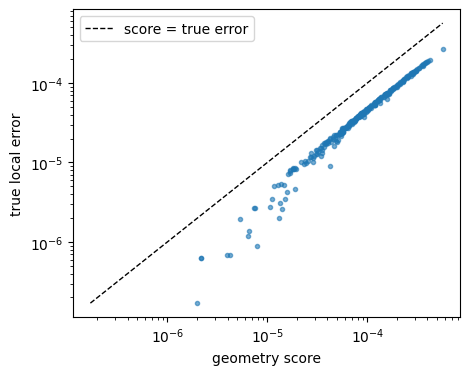

In [31]:
# ── Geometry score: estimated local error of a stencil, from its shape only (no solution values) ──
# The 3 rows cancel the Taylor terms of order 0, 1, 2. What is left starts with the order-3 and
# order-4 terms. With the PDE substituted, those terms are the heat polynomials T3, T4 in xi = dx - a dt.
L_SOL = 1 / (2 * np.pi)        # solution length scale: shortest mode of the IC, sin(2 pi x)

def score(DX, DT, w, a_loc):
    """DX, DT = neighbour offsets from p (physical units), w = weights."""
    xi = DX - a_loc * DT
    m3 = w @ (xi**3 + 6 * alpha * DT * xi)                                 # leftover on T3
    m4 = w @ (xi**4 + 12 * alpha * DT * xi**2 + 12 * (alpha * DT)**2)      # leftover on T4
    return abs(m3) / (6 * L_SOL**3) + abs(m4) / (24 * L_SOL**4)

# ── Check: score vs the true local error, for random admissible stencils at p = (50, 20) ──
# true local error delta_p = u(p) - sum w u(q), with exact values (u_true used ONLY for this check)
rng = np.random.default_rng()
p = (50, 20)
cells = [(i, j) for j in (-1, -2, -3) for i in range(-3, 4)]               # 3 levels down, |dix| <= 3
S, D = [], []
while len(S) < 300:
    nb = [cells[k] for k in rng.choice(len(cells), 5, replace=False)]
    DX, DT = np.array([q[0] for q in nb]) * dx, np.array([q[1] for q in nb]) * dt
    w = solve_weights(DX, DT, c)
    if w is None:
        continue
    u_nb = np.array([u_true((p[0] + q[0]) * dx, (p[1] + q[1]) * dt)[0] for q in nb])
    S.append(score(DX, DT, w, c))
    D.append(abs(u_true(p[0] * dx, p[1] * dt)[0] - w @ u_nb))
S, D = np.array(S), np.array(D)
print(f"300 admissible stencils at p = {p}: corr(log score, log true error) = {np.corrcoef(np.log(S), np.log(D))[0, 1]:.2f}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.loglog(S, D, '.', alpha=0.6)
lim = [min(S.min(), D.min()), max(S.max(), D.max())]
ax.loglog(lim, lim, 'k--', lw=1, label='score = true error')
ax.set_xlabel('geometry score'); ax.set_ylabel('true local error'); ax.legend(); plt.show()

### Backward map and influence β
**The map.** Start at $z^*$ and give it a stencil. Each neighbour that is not known data (IC or wall) becomes a new point that also needs a stencil. Repeat until every branch ends on the IC or a wall. Points are expanded **latest $t$ first**.

**Influence.** $\beta_p$ = how much an error at $p$ changes the value at $z^*$. Start with $\beta_{z^*}=1$. When $p$ is expanded with weights $w$, pass its influence down: $\beta_q \mathrel{+}= \beta_p\,w_q$. Because we go latest-$t$ first, every point that uses $p$ has already been expanded, so $\beta_p$ is complete by the time $p$ is expanded.

**Exact identity.** With $\delta_p=u_p-\sum_q w_qu_q$ the local error at $p$,
$$e(z^*)=\sum_p\beta_p\,\delta_p ,\qquad |e(z^*)|\le\sum_p|\beta_p\,\delta_p|\ \ (\text{exact bound})\ \approx\ \sum_p|\beta_p|\,s_p\ \ (\text{score estimate}).$$
This is the adjoint representation of the error (Becker & Rannacher 2001), the exact version of thesis Corollary 2.7.
Check: give every point the Lax–Wendroff stencil. The map must reproduce LW from cell 3, and the identity must hold.

In [32]:
# ── Known data: the initial condition and the walls are given, not computed ──
U0 = u_true(x_grid, 0.0)
is_known    = lambda q: q[1] == 0 or q[0] in (0, nx - 1)
known_value = lambda q: U0[q[0]] if q[1] == 0 else 0.0
a_loc = c              # linear PDE: a(u) = c everywhere (a nonlinear PDE needs u near p here)

_w_cache = {}
def weights(p, nbs):
    """Taylor weights of p's neighbours nbs (grid points); None if not admissible. Cached by shape."""
    offs = tuple((q[0] - p[0], q[1] - p[1]) for q in nbs)
    if offs not in _w_cache:
        _w_cache[offs] = solve_weights(np.array([o[0] for o in offs]) * dx, np.array([o[1] for o in offs]) * dt, a_loc)
    return _w_cache[offs]

def point_score(p, nbs, w):
    return score(np.array([q[0] - p[0] for q in nbs]) * dx, np.array([q[1] - p[1] for q in nbs]) * dt, w, a_loc)

# ── The map, built backward from z* ──
# Points wait in `pending` and are expanded LATEST t first: every point that can use p is later
# than p, so it is already expanded and p's influence beta_p is complete when p is expanded.
def start_map(z_star):
    return {"z_star": z_star, "pending": [(-z_star[1], z_star[0])], "beta": {z_star: 1.0}, "stencil": {}}

def next_point(m):
    it, ix = m["pending"][0]
    return (ix, -it)

def expand(m, nbs):
    """Give the next point the stencil nbs and pass its influence down: beta_q += beta_p * w_q."""
    it, ix = heapq.heappop(m["pending"])
    p = (ix, -it)
    w = weights(p, nbs)
    m["stencil"][p] = (nbs, w)
    for q, wq in zip(nbs, w):
        if is_known(q):
            continue                                   # IC or wall: exact, the map stops here
        if q not in m["beta"]:
            m["beta"][q] = 0.0
            heapq.heappush(m["pending"], (-q[1], q[0]))
        m["beta"][q] += m["beta"][p] * wq
    return p, w

def build_map(z_star, choose):
    """Whole map; choose(m, p) returns the neighbours of p."""
    m = start_map(z_star)
    while m["pending"]:
        expand(m, choose(m, next_point(m)))
    return m

# ── Forward pass: values bottom-up, from the IC and walls to z* ──
def evaluate(m):
    u_hat = {}
    value = lambda q: known_value(q) if is_known(q) else u_hat[q]
    for p in sorted(m["stencil"], key=lambda p: p[1]):          # increasing t: neighbours are ready
        nbs, w = m["stencil"][p]
        u_hat[p] = sum(wq * value(q) for q, wq in zip(nbs, w))
    return u_hat

### Window, admissible stencils and the mask
**Window.** The candidate neighbours of $p$ are the 21 cells up to 3 to each side and 1 to 3 levels below $p$. A cell past a wall or below $t=0$ is moved onto the wall or the IC (known data).
**Admissible stencils.** Every choice of 5 cells whose weights pass the admissibility test (cell 3). Interior points all share the same list, so it is computed once and cached.
**Mask.** The agent will pick the 5 cells one at a time. A cell may be picked next only if some admissible stencil contains it together with the picks so far, so the agent can never end up with a bad stencil.
**First rule without RL:** every point takes its lowest-score stencil.

21 window cells | interior point: 18694 admissible stencils of 20349
first pick allowed on 21 cells
lowest score: 670 points, error 1.48e-07
LW          : 400 points, error 3.02e-05
lowest-score stencil at an interior point (dix, dit): [(3, -1), (-3, -2), (0, -2), (-1, -3), (2, -3)]


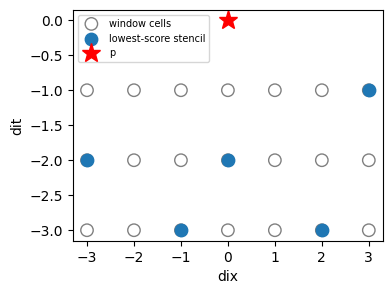

In [33]:
# ── The window: candidate neighbour cells below p ──
R_X, K_T = 3, 3                       # |dix| <= 3 cells, 1 to 3 levels down
WINDOW  = [(dix, dit) for dit in range(-1, -K_T - 1, -1) for dix in range(-R_X, R_X + 1)]
N_CELLS = len(WINDOW)
N_NB    = 5                           # neighbours per stencil

def place(p, k):
    """Grid point of window cell k seen from p. Past a wall or below t = 0 -> moved onto it."""
    return (min(max(p[0] + WINDOW[k][0], 0), nx - 1), max(p[1] + WINDOW[k][1], 0))

# ── Every admissible stencil at p (cached: interior points all share one list) ──
_sets_cache = {}
def admissible(p):
    """(stencils as tuples of cells, cell-usage matrix, scores). Cells that land on the same point count once."""
    key = tuple((place(p, k)[0] - p[0], place(p, k)[1] - p[1]) for k in range(N_CELLS))   # p's local situation
    if key not in _sets_cache:
        cells, seen = [], set()
        for k in range(N_CELLS):
            if place(p, k) not in seen:
                seen.add(place(p, k)); cells.append(k)
        sets, scores = [], []
        for s in itertools.combinations(cells, min(N_NB, len(cells))):
            nbs = [place(p, k) for k in s]
            w = weights(p, nbs)
            if w is not None:
                sets.append(s); scores.append(point_score(p, nbs, w))
        uses = np.zeros((len(sets), N_CELLS), dtype=bool)
        for i, s in enumerate(sets):
            uses[i, list(s)] = True
        _sets_cache[key] = (sets, uses, np.array(scores))
    return _sets_cache[key]

def pick_mask(p, picks):
    """Cell k may be picked next if some admissible stencil contains the picks so far plus k."""
    _, uses, _ = admissible(p)
    ok = uses[:, picks].all(axis=1) if picks else np.ones(len(uses), dtype=bool)
    mask = uses[ok].any(axis=0)
    mask[picks] = False
    return mask

# ── A first rule without RL: every point takes its lowest-score stencil ──
def lowest_score(m, p):
    sets, _, sc = admissible(p)
    return [place(p, k) for k in sets[int(np.argmin(sc))]]

sets, _, sc = admissible((50, 20))
print(f"{N_CELLS} window cells | interior point: {len(sets)} admissible stencils of "
      f"{len(list(itertools.combinations(range(N_CELLS), N_NB)))}")
print("first pick allowed on", pick_mask((50, 20), []).sum(), "cells")

z = (50, 20)
m = build_map(z, lowest_score)
err = abs(u_true(z[0] * dx, z[1] * dt)[0] - evaluate(m)[z])          # u_true ONLY for reporting
print(f"lowest score: {len(m['stencil'])} points, error {err:.2e}")
print(f"LW          : {fd_reference(*z, 'LW')[2]} points, error {fd_reference(*z, 'LW')[1]:.2e}")

# ── Picture: the window at an interior point and the lowest-score stencil ──
best = sets[int(np.argmin(sc))]
print("lowest-score stencil at an interior point (dix, dit):", [WINDOW[k] for k in best])
fig, ax = plt.subplots(figsize=(4, 3))
ax.scatter(*np.array(WINDOW).T, s=80, facecolors='none', edgecolors='gray', label='window cells')
ax.scatter(*np.array([WINDOW[k] for k in best]).T, s=80, color='tab:blue', label='lowest-score stencil')
ax.plot(0, 0, 'r*', ms=14, label='p')
ax.set_xlabel('dix'); ax.set_ylabel('dit'); ax.legend(fontsize=7, loc='upper left'); plt.show()

### Environment
**Episode.** Build one map for the query $z^*$. At each step the agent picks one window cell for the current point (the latest-$t$ pending point). After 5 picks the stencil is complete, the point is expanded (cell 5), and the next point comes up. The episode ends when no points are pending.
**Mask.** Only cells that can still complete an admissible stencil are allowed (cell 6). Points with a single admissible stencil (next to the IC) are played automatically.
**Reward**, given each time a stencil is complete:
$$r_p=-\frac{|\beta_p|\,s_p}{B_{\rm LW}}-\lambda\,\frac{\text{new points}}{N_{\rm LW}},$$
where $B_{\rm LW}$ and $N_{\rm LW}$ are the score sum and point count of the Lax–Wendroff map of the same $z^*$. So the total return is $-B/B_{\rm LW}-\lambda(N-1)/N_{\rm LW}$, and LW itself scores $\approx -1-\lambda$.
**Cap.** If the map grows past $3N_{\rm LW}$ points, the episode stops, and each point left unexpanded costs its worst stencil.
**State**, for the current point $p$:
- per window cell: already picked, already in the map (reusing it is free), known data (IC/wall), and the best score still reachable through it;
- and globally: $\log|\beta_p|$, levels above the IC, offset to $z^*$, pick number, points used so far, and the pending workload (points still waiting and their total influence).

obs size 91 | 3090 picks | finished: True | 618 points (1.54x LW) | score sum 15.2x LW
sum of rewards -16.721   check: -score_ratio - lam*(points-1)/N_ref = -16.721
random map: {'points': 618, 'work': 3090, 'error': '5.07e-05', 'bound': '6.10e-04'}
LW map:     {'points': 400, 'work': 1200, 'error': '3.02e-05', 'bound': '3.02e-05'}


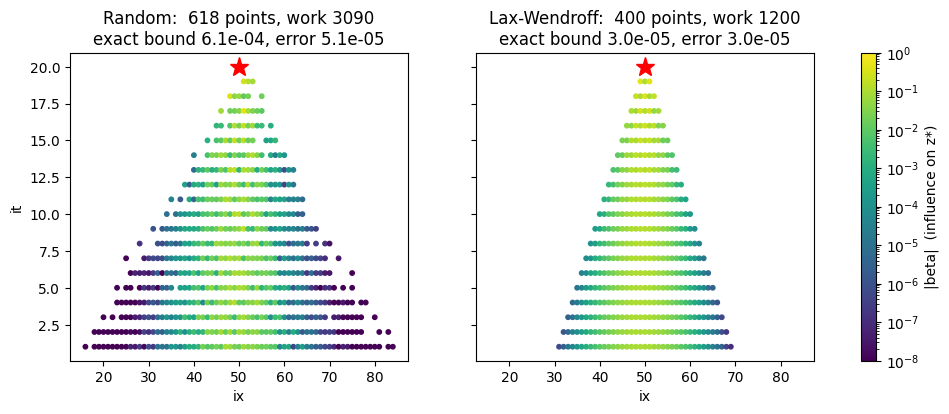

In [34]:
# ── Report of a finished map: points, work, true error, exact bound (u_true ONLY for reporting) ──
# ── Lax-Wendroff as a map rule: 3 points one level down (the reward's ruler, and a baseline) ──
lw = lambda m, p: [(p[0] - 1, p[1] - 1), (p[0], p[1] - 1), (p[0] + 1, p[1] - 1)]
def report(m):
    U = lambda q: u_true(q[0] * dx, q[1] * dt)[0]
    z = m["z_star"]
    delta = {p: U(p) - sum(wq * U(q) for q, wq in zip(nbs, w)) for p, (nbs, w) in m["stencil"].items()}
    return {"points": len(m["stencil"]),
            "work":   sum(len(nbs) for nbs, _ in m["stencil"].values()),       # points x neighbours
            "error":  abs(U(z) - evaluate(m)[z]),
            "bound":  sum(abs(m["beta"][p] * delta[p]) for p in delta)}

# ── Reference for normalising the reward: the Lax-Wendroff map of the same z* ──
_ref_cache = {}
def reference(z):
    """(score sum, points) of LW's map. A return of -1 - lam means 'as good as LW'."""
    if z not in _ref_cache:
        m = build_map(z, lw)
        _ref_cache[z] = (sum(abs(m["beta"][p]) * point_score(p, *m["stencil"][p]) for p in m["stencil"]), len(m["stencil"]))
    return _ref_cache[z]

# ── Environment: one step = one pick; a reward each time a stencil is complete ──
N_OBS = 4 * N_CELLS + 7

class MapEnv(gym.Env):
    def __init__(self, queries, lam=1.0, cap=3.0):
        super().__init__()
        self.queries, self.lam, self.cap = queries, lam, cap
        self.observation_space = spaces.Box(-np.inf, np.inf, shape=(N_OBS,), dtype=np.float32)
        self.action_space = spaces.Discrete(N_CELLS)               # one action = one window cell

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.z = self.queries[self.np_random.integers(len(self.queries))]
        self.B_ref, self.N_ref = reference(self.z)
        self.m, self.picks, self.B = start_map(self.z), [], 0.0
        self._play_forced()
        return self._obs(), {}

    def _complete(self, cells):
        """Expand the next point with these cells; reward = -|beta_p| s_p / B_ref - lam * new points / N_ref."""
        p = next_point(self.m)
        nbs = [place(p, k) for k in cells]
        n_new = sum(1 for q in set(nbs) if not is_known(q) and q not in self.m["beta"])
        _, w = expand(self.m, nbs)
        term = abs(self.m["beta"][p]) * point_score(p, nbs, w)
        self.B += term
        return -term / self.B_ref - self.lam * n_new / self.N_ref

    def _play_forced(self):
        """Points with only one admissible stencil (e.g. next to the IC) need no decision."""
        r = 0.0
        while self.m["pending"] and len(admissible(next_point(self.m))[0]) == 1:
            r += self._complete(admissible(next_point(self.m))[0][0])
        return r

    def _obs(self):
        if not self.m["pending"]:
            return np.zeros(N_OBS, np.float32)
        p = next_point(self.m)
        picked, exists, known = np.zeros(N_CELLS), np.zeros(N_CELLS), np.zeros(N_CELLS)
        picked[self.picks] = 1
        for k in range(N_CELLS):
            q = place(p, k)
            known[k], exists[k] = is_known(q), q in self.m["beta"]      # exists = reusing it creates no new point
        # per cell: log10(best score still reachable through it / best score at p), capped at 3
        _, uses, sc = admissible(p)
        rel = np.log10(sc / sc.min())
        ok = uses[:, self.picks].all(axis=1) if self.picks else np.ones(len(rel), dtype=bool)
        reach = np.where(uses[ok], rel[ok, None], 3.0).min(axis=0)
        reach[self.picks] = 3.0
        pend = [(ix, -it) for it, ix in self.m["pending"]]
        glob = [np.log10(abs(self.m["beta"][p]) + 1e-12),          # influence of p on z*
                p[1],                                              # levels above the IC
                p[0] - self.z[0],                                  # offset to z* in x
                len(self.picks),                                   # pick number
                len(self.m["stencil"]) / self.N_ref,               # points used so far
                len(pend) / self.N_ref,                            # points still waiting for a stencil
                sum(abs(self.m["beta"][q]) for q in pend)]         # their total influence
        return np.concatenate([picked, exists, known, np.minimum(reach, 3.0), glob]).astype(np.float32)

    def step(self, k):
        self.picks.append(int(k))
        p = next_point(self.m)
        if len(self.picks) < len(admissible(p)[0][0]):             # still choosing p's stencil
            return self._obs(), 0.0, False, False, {}
        r = self._complete(self.picks)
        self.picks = []
        r += self._play_forced()
        n = len(self.m["stencil"]) + len(self.m["pending"])
        if self.m["pending"] and n <= self.cap * self.N_ref:       # map not finished
            return self._obs(), r, False, False, {}
        # finished, or over the point cap: each point left unexpanded costs its worst admissible stencil
        for it, ix in self.m["pending"]:
            q = (ix, -it)
            r -= abs(self.m["beta"][q]) * admissible(q)[2].max() / self.B_ref
        info = {"finished": not self.m["pending"], "points": len(self.m["stencil"]),
                "score_ratio": self.B / self.B_ref, "points_ratio": len(self.m["stencil"]) / self.N_ref}
        return np.zeros(N_OBS, np.float32), r, True, False, info

    def action_masks(self):
        return pick_mask(next_point(self.m), self.picks)

# ── Check: one episode with random (masked) picks ──
env = MapEnv(queries=[(50, 20)], lam=1.0)
obs, _ = env.reset()
rng, total, steps, done = np.random.default_rng(), 0.0, 0, False
while not done:
    obs, r, done, _, info = env.step(rng.choice(np.flatnonzero(env.action_masks())))
    total += r; steps += 1
print(f"obs size {N_OBS} | {steps} picks | finished: {info['finished']} | {info['points']} points "
      f"({info['points_ratio']:.2f}x LW) | score sum {info['score_ratio']:.1f}x LW")
print(f"sum of rewards {total:.3f}   check: -score_ratio - lam*(points-1)/N_ref = "
      f"{-info['score_ratio'] - env.lam * (info['points'] - 1) / env.N_ref:.3f}")
print("random map:", {k: (f'{v:.2e}' if isinstance(v, float) else v) for k, v in report(env.m).items()})
print("LW map:    ", {k: (f'{v:.2e}' if isinstance(v, float) else v) for k, v in report(build_map((50, 20), lw)).items()})
 # ── Picture: the random map next to the LW map, coloured by influence ──
from matplotlib.colors import LogNorm
maps = {"Random": env.m, "Lax-Wendroff": build_map((50, 20), lw)}
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
for ax, (name, mm) in zip(axes, maps.items()):
    P = np.array(list(mm["stencil"]))
    sc = ax.scatter(P[:, 0], P[:, 1], c=[abs(mm["beta"][tuple(p)]) for p in P], s=10,
                    cmap="viridis", norm=LogNorm(1e-8, 1))
    ax.plot(*mm["z_star"], 'r*', ms=14)
    rep = report(mm)
    ax.set_title(f"{name}:  {rep['points']} points, work {rep['work']}\nexact bound {rep['bound']:.1e}, error {rep['error']:.1e}")
    ax.set_xlabel("ix")
axes[0].set_ylabel("it")
fig.colorbar(sc, ax=axes, label="|beta|  (influence on z*)")
plt.show()

### Map figure
One figure for any finished map, used for the random check, the baselines and the training videos:
1. the map, coloured by influence $|\beta_p|$ on $z^*$;
2. a zoom on $z^*$ with the stencils of the top levels;
3. the accumulated error $|\hat u_p-u_p|$ at every computed point;
4. the error share $|\beta_p\delta_p|$ of every point (these add up to the exact bound).

Panels 3 and 4 use the exact solution, only for this figure.

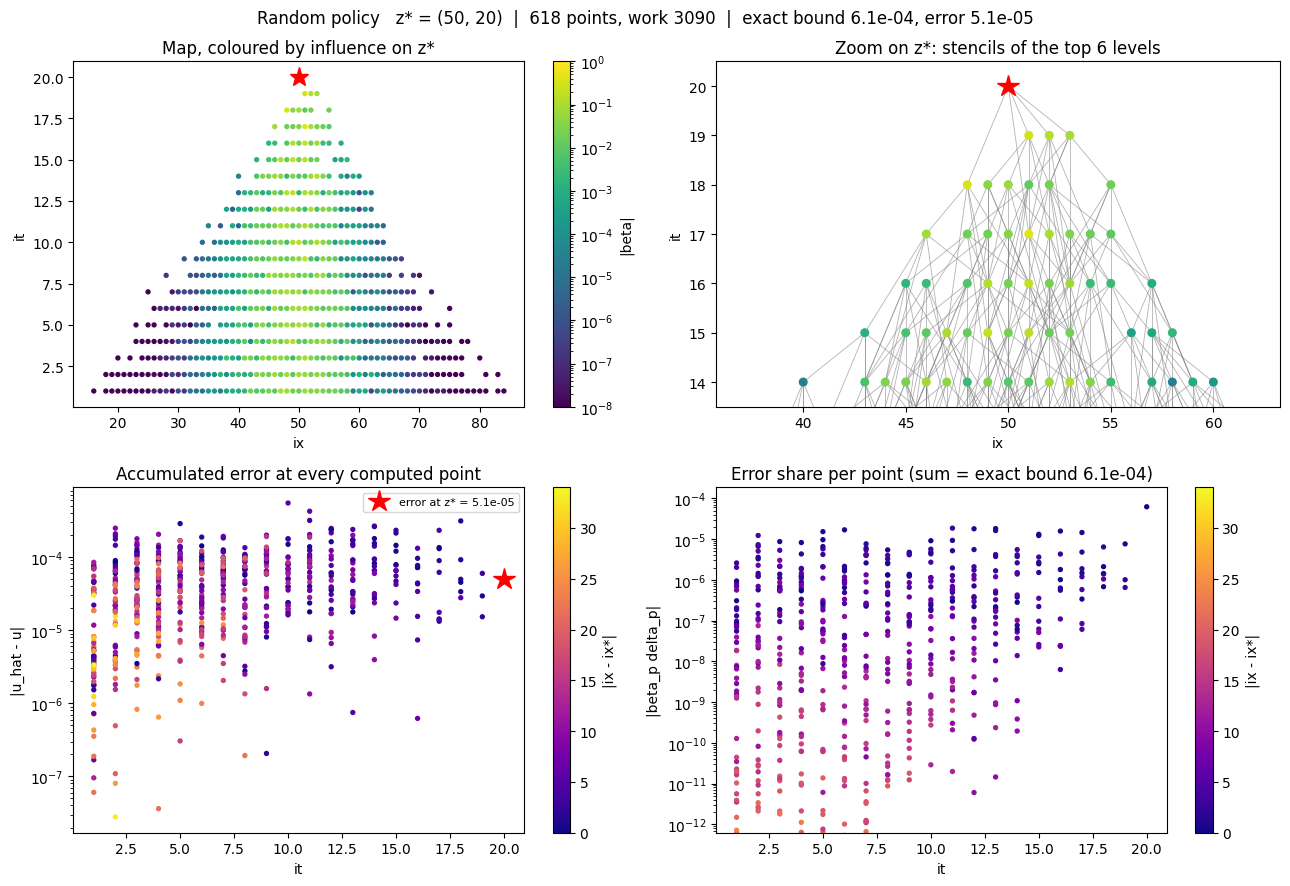

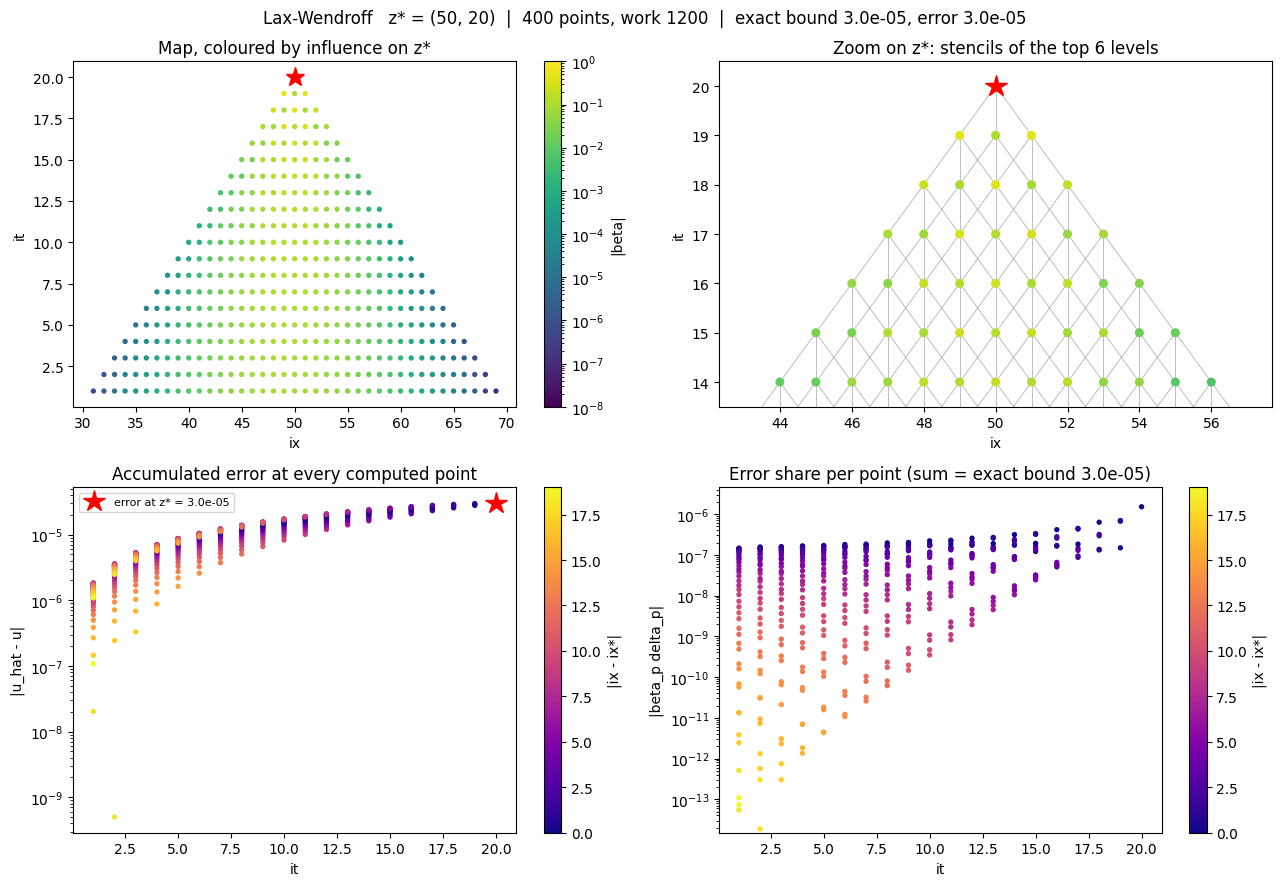

In [35]:
# ── One figure for any finished map (used for the random check, the baselines and the training videos) ──
from matplotlib.colors import LogNorm

def plot_map(m, title="", path=None):
    """2x2: the map coloured by influence | zoom on z* with stencils | accumulated error | error share per point.
    u_true is used ONLY for the last two panels. Saves to `path` if given, otherwise shows."""
    z, rep = m["z_star"], report(m)
    U = lambda q: u_true(q[0] * dx, q[1] * dt)[0]
    pts = list(m["stencil"])
    P = np.array(pts)
    beta = np.array([abs(m["beta"][p]) for p in pts])
    share = np.array([abs(m["beta"][p] * (U(p) - sum(wq * U(q) for q, wq in zip(*m["stencil"][p])))) for p in pts])
    u_hat = evaluate(m)

    fig, ((a1, a2), (a3, a4)) = plt.subplots(2, 2, figsize=(13, 9))

    # (1) the whole map, coloured by influence on z*
    sc = a1.scatter(P[:, 0], P[:, 1], c=beta, s=8, cmap="viridis", norm=LogNorm(1e-8, 1))
    a1.plot(*z, 'r*', ms=14)
    fig.colorbar(sc, ax=a1, label="|beta|")
    a1.set_xlabel("ix"); a1.set_ylabel("it"); a1.set_title("Map, coloured by influence on z*")

    # (2) zoom on z*: the stencils of the top levels
    top = [p for p in pts if p[1] >= z[1] - 2 * K_T]
    for p in top:
        for q in m["stencil"][p][0]:
            a2.plot([p[0], q[0]], [p[1], q[1]], '-', color='gray', lw=0.6, alpha=0.6)
    T = np.array(top)
    a2.scatter(T[:, 0], T[:, 1], c=[abs(m["beta"][p]) for p in top], s=30, cmap="viridis", norm=LogNorm(1e-8, 1), zorder=3)
    a2.plot(*z, 'r*', ms=16, zorder=4)
    a2.set_ylim(z[1] - 2 * K_T - 0.5, z[1] + 0.5)
    a2.set_xlabel("ix"); a2.set_ylabel("it"); a2.set_title(f"Zoom on z*: stencils of the top {2 * K_T} levels")

    # (3) accumulated error: |u_hat - u| at every computed point
    acc = np.array([abs(u_hat[p] - U(p)) for p in pts])
    sc = a3.scatter(P[:, 1], np.maximum(acc, 1e-16), c=np.abs(P[:, 0] - z[0]), s=8, cmap="plasma")
    a3.plot(z[1], rep["error"], 'r*', ms=16, label=f"error at z* = {rep['error']:.1e}")
    fig.colorbar(sc, ax=a3, label="|ix - ix*|")
    a3.set_yscale("log"); a3.set_xlabel("it"); a3.set_ylabel("|u_hat - u|"); a3.legend(fontsize=8)
    a3.set_title("Accumulated error at every computed point")

    # (4) where the error comes from: |beta_p delta_p| for every point
    sc = a4.scatter(P[:, 1], np.maximum(share, 1e-16), c=np.abs(P[:, 0] - z[0]), s=8, cmap="plasma")
    fig.colorbar(sc, ax=a4, label="|ix - ix*|")
    a4.set_yscale("log"); a4.set_ylim(max(share.max() * 1e-8, 1e-16), share.max() * 3)
    a4.set_xlabel("it"); a4.set_ylabel("|beta_p delta_p|")
    a4.set_title(f"Error share per point (sum = exact bound {rep['bound']:.1e})")

    fig.suptitle(f"{title}   z* = {z}  |  {rep['points']} points, work {rep['work']}  |  "
                 f"exact bound {rep['bound']:.1e}, error {rep['error']:.1e}")
    plt.tight_layout()
    if path:
        fig.savefig(path, dpi=100, bbox_inches="tight"); plt.close(fig)
    else:
        plt.show()

plot_map(env.m, "Random policy")
plot_map(build_map((50, 20), lw), "Lax-Wendroff")

### Training helpers and callbacks
- `make_env`: one training environment (with the action mask and the episode monitor).
- `run_policy`: one episode where the policy takes its most likely pick every time; returns the finished map.
- `MapLogCallback`: logs points, score sum (both relative to LW) and the finish rate of the training episodes to TensorBoard.
- `SnapshotCallback`: every `every` steps, runs the current policy on one query, saves its map figure (cell 8) and keeps its numbers. These images become the training-progress video.
Check: a tiny run (2 environments, 4096 steps) to see that everything connects.

In [36]:
# ── Helpers for training: environment factory and one greedy run of a trained policy ──
def make_env(queries, lam, seed):
    def _init():
        env = Monitor(ActionMasker(MapEnv(queries=queries, lam=lam), lambda e: e.action_masks()))
        env.reset(seed=seed)
        return env
    return _init

def run_policy(model, z, lam):
    """One episode on z* with the policy's most likely picks. Returns the finished env (map in env.m)."""
    env = MapEnv(queries=[z], lam=lam)
    obs, _ = env.reset(seed=0)
    done, ret = False, 0.0
    while not done:
        a, _ = model.predict(obs, action_masks=env.action_masks(), deterministic=True)
        obs, r, done, _, info = env.step(a)
        ret += r
    env.ret, env.info = ret, info
    return env

# ── Callback 1: log map numbers of every finished training episode (mean of the last 100) ──
class MapLogCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.hist = {"points_ratio": [], "score_ratio": [], "finished": []}

    def _on_step(self):
        for info in self.locals["infos"]:
            if "points_ratio" in info:                              # only at the end of an episode
                for k in self.hist:
                    self.hist[k].append(float(info[k]))
        for k, v in self.hist.items():
            if v:
                self.logger.record(f"map/{k}", np.mean(v[-100:]))
        return True

# ── Callback 2: every `every` steps, run the current policy on z_plot, save the figure and the numbers ──
class SnapshotCallback(BaseCallback):
    def __init__(self, z_plot, lam, every, img_dir):
        super().__init__()
        self.z_plot, self.lam, self.every, self.img_dir = z_plot, lam, every, img_dir
        self.last, self.hist, self.episodes = -every, [], 0

    def _on_step(self):
        self.episodes += sum("episode" in info for info in self.locals["infos"])   # maps finished in training
        if self.num_timesteps - self.last >= self.every:
            self.last = self.num_timesteps
            env = run_policy(self.model, self.z_plot, self.lam)
            if env.info["finished"]:
                rep = report(env.m)
                plot_map(env.m, f"step {self.num_timesteps:,}  ({self.episodes} maps)  |  return {env.ret:.2f}",
                         os.path.join(self.img_dir, f"map_{self.num_timesteps:09d}.png"))
            else:
                rep = {"points": env.info["points"], "work": np.nan, "error": np.nan, "bound": np.nan}
            self.hist.append({"step": self.num_timesteps, "episodes": self.episodes, "return": env.ret, **rep})
            print(f"step {self.num_timesteps:>10,} | {self.episodes:5d} maps: return {env.ret:7.2f} | "
                  f"{rep['points']} points | bound {rep['bound']:.1e} | finished {env.info['finished']}")
        return True

### Training
MaskablePPO with $\gamma=1$ and `gae_lambda=1.0`: each pick is judged by the actual return of the rest of the episode. That is what fixed the drift to big maps in notebook 10.
Everything a run produces goes into one folder:
`runs{month}-{day}/{run_name}/config.json` (all settings), and for each seed: `images/` (snapshot figures + final map), `checkpoints/` (models), `logs/` (TensorBoard), `snapshots.json` (return, points, work, error, bound at every snapshot).

In [ ]:
import json, time
from stable_baselines3.common.callbacks import CheckpointCallback

# ── Training settings ──
QUERIES   = [(50, 20)]          # training queries z*
Z_PLOT    = (50, 20)            # query used for the snapshots / video
LAM       = 1.0                 # price of one new point (in units of LW's point count)
SEEDS     = [1]
TOTAL     = 5_000_000           # environment steps (= picks) per seed
N_ENVS    = 12
SNAP_EVERY, CKPT_EVERY = 100_000, 500_000
PPO_KW    = dict(n_steps=256, batch_size=256, gamma=1.0, gae_lambda=1.0, learning_rate=3e-4, ent_coef=0.0)

# ── Run folder: everything this run produces goes here ──
run_name = f"single_z{Z_PLOT[0]}-{Z_PLOT[1]}_lam{LAM:g}_R{R_X}K{K_T}"
run_dir  = os.path.join(f"runs{date.today().month}-{date.today().day}", run_name)
os.makedirs(run_dir, exist_ok=True)
config = dict(queries=QUERIES, z_plot=Z_PLOT, lam=LAM, seeds=SEEDS, total=TOTAL, n_envs=N_ENVS,
              window=dict(R_X=R_X, K_T=K_T, N_NB=N_NB), admissible=dict(COND_MAX=COND_MAX, W_MAX=W_MAX),
              pde=dict(alpha=alpha, c=c, nx=nx, nt=nt), ppo=PPO_KW, date=str(date.today()))
with open(os.path.join(run_dir, "config.json"), "w") as f:
    json.dump(config, f, indent=2)
print("run folder:", run_dir)

# fill the caches once here; every worker process gets a copy instead of recomputing them
for z in QUERIES:
    reference(z); build_map(z, lowest_score)

for seed in SEEDS:
    seed_dir = os.path.join(run_dir, f"seed{seed}")
    img_dir, ckpt_dir = os.path.join(seed_dir, "images"), os.path.join(seed_dir, "checkpoints")
    os.makedirs(img_dir, exist_ok=True); os.makedirs(ckpt_dir, exist_ok=True)
    print(f"\n{'#' * 40}\nSEED {seed}\n{'#' * 40}")

    vec = SubprocVecEnv([make_env(QUERIES, LAM, seed=100 * seed + i) for i in range(N_ENVS)])
    model = MaskablePPO("MlpPolicy", vec, seed=seed, verbose=0, device="cpu",
                        tensorboard_log=os.path.join(seed_dir, "logs"), **PPO_KW)
    snap_cb = SnapshotCallback(Z_PLOT, LAM, every=SNAP_EVERY, img_dir=img_dir)
    t0 = time.time()
    model.learn(total_timesteps=TOTAL, tb_log_name="ppo",
                callback=[MapLogCallback(), snap_cb,
                          CheckpointCallback(save_freq=max(CKPT_EVERY // N_ENVS, 1), save_path=ckpt_dir, name_prefix="ppo")])
    vec.close()
    print(f"training time: {(time.time() - t0) / 60:.0f} min")

    # save: final model, the snapshot numbers, and the final map figure
    model.save(os.path.join(ckpt_dir, "ppo_final"))
    with open(os.path.join(seed_dir, "snapshots.json"), "w") as f:
        json.dump(snap_cb.hist, f, indent=1, default=float)
    env = run_policy(model, Z_PLOT, LAM)
    plot_map(env.m, f"final  |  return {env.ret:.2f}", os.path.join(img_dir, "map_final.png"))
    print("final:", {k: (f"{v:.2e}" if isinstance(v, float) else v) for k, v in report(env.m).items()},
          f"| return {env.ret:.2f}  (LW = {-1 - LAM * (reference(Z_PLOT)[1] - 1) / reference(Z_PLOT)[1]:.2f})")

### Videos and learning curves
From a finished run folder (no training here): the learning curves against the baselines, the training-progress video (the snapshot figures in order), and two build videos (the trained policy and Lax–Wendroff building their maps from $z^*$ down).

In [37]:
import imageio_ffmpeg; print(imageio_ffmpeg.get_ffmpeg_exe())

C:\Users\amt35\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\imageio_ffmpeg\binaries\ffmpeg-win-x86_64-v7.1.exe


In [38]:
from map_progress_video import make_progress_video
from map_build_video import make_build_video
from learning_curves import plot_learning_curves

seed_dir = os.path.join(run_dir, f"seed{SEEDS[0]}")            # or paste the path of a copied run folder
img_dir  = os.path.join(seed_dir, "images")
model    = MaskablePPO.load(os.path.join(seed_dir, "checkpoints", "ppo_final"))

def baseline(rule):
    """Return, points and exact bound of a fixed rule's map, on the same reward as the agent."""
    mm, (B_ref, N_ref) = build_map(Z_PLOT, rule), reference(Z_PLOT)
    rep = report(mm)
    B = sum(abs(mm["beta"][p]) * point_score(p, *mm["stencil"][p]) for p in mm["stencil"])
    return {"return": -B / B_ref - LAM * (rep["points"] - 1) / N_ref, "points": rep["points"], "bound": rep["bound"]}

baselines = {"LW": baseline(lw), "lowest score": baseline(lowest_score)}
for name, b in baselines.items():
    print(f"{name:12s}: return {b['return']:.2f}, {b['points']} points, bound {b['bound']:.1e}")
plot_learning_curves(os.path.join(seed_dir, "snapshots.json"), baselines)
make_progress_video(img_dir, fps=2)
env = run_policy(model, Z_PLOT, LAM)
make_build_video(env.m, os.path.join(img_dir, "build_final.mp4"), is_known, title=f"trained policy, seed {SEEDS[0]}")
make_build_video(build_map(Z_PLOT, lw), os.path.join(img_dir, "build_LW.mp4"), is_known, title="Lax-Wendroff")

NameError: name 'run_dir' is not defined

In [18]:
import importlib, map_progress_video, map_build_video
importlib.reload(map_progress_video); importlib.reload(map_build_video)
from map_progress_video import make_progress_video
from map_build_video import make_build_video

### Comparison 1: the best fixed stencil
Brute force: every interior admissible stencil is tried as a fixed rule, used at every point where it is admissible (points next to the walls or the IC take their lowest-score stencil). Each map is ranked by the same return as the agent (LW ruler, same $\lambda$).
If a single fixed stencil beats the agent, the agent has not learned anything a plain search can't find.

In [39]:
# ── Comparison 1: the best FIXED stencil (brute force over every interior admissible stencil) ──
# Each candidate s is used at every point where it is admissible; elsewhere (next to the walls / the IC)
# the point takes its lowest-score stencil. Ranked by the same return as the agent (LW ruler, same LAM).
from joblib import Parallel, delayed

def fixed_rule(s):
    allowed = {}
    def choose(m, p):
        key = tuple((place(p, k)[0] - p[0], place(p, k)[1] - p[1]) for k in range(N_CELLS))
        if key not in allowed:
            allowed[key] = set(admissible(p)[0])
        return [place(p, k) for k in s] if s in allowed[key] else lowest_score(m, p)
    return choose

def map_return(m, z, lam):
    B_ref, N_ref = reference(z)
    B = sum(abs(m["beta"][p]) * point_score(p, *m["stencil"][p]) for p in m["stencil"])
    return -B / B_ref - lam * (len(m["stencil"]) - 1) / N_ref

def fixed_chunk(chunk, z, lam):
    return [(s, map_return(m, z, lam), len(m["stencil"])) for s in chunk for m in [build_map(z, fixed_rule(s))]]

Z_CMP = Z_PLOT
interior = admissible(Z_CMP)[0]
t0 = time.time()
parts = Parallel(n_jobs=N_ENVS)(delayed(fixed_chunk)([interior[i] for i in idx], Z_CMP, LAM)
                                  for idx in np.array_split(np.arange(len(interior)), N_ENVS))
rows = sorted((r for part in parts for r in part), key=lambda r: -r[1])
print(f"{len(rows)} fixed stencils in {time.time() - t0:.0f} s")

agent = run_policy(model, Z_CMP, LAM)
print(f"\nagent  : return {agent.ret:6.2f} | " + " | ".join(f"{k} {v:.1e}" if isinstance(v, float) else f"{k} {v}" for k, v in report(agent.m).items()))
for name, rule in [("LW", lw), ("lowest score", lowest_score)]:
    mm = build_map(Z_CMP, rule)
    print(f"{name:7s}: return {map_return(mm, Z_CMP, LAM):6.2f} | " + " | ".join(f"{k} {v:.1e}" if isinstance(v, float) else f"{k} {v}" for k, v in report(mm).items()))
print("\nbest fixed stencils:")
for s, ret, n in rows[:5]:
    rep = report(build_map(Z_CMP, fixed_rule(s)))
    print(f"   {[WINDOW[k] for k in s]}: return {ret:6.2f} | points {n} | work {rep['work']} | bound {rep['bound']:.1e}")
print(f"\nfixed stencils that beat the agent: {sum(r[1] > agent.ret for r in rows)} of {len(rows)}")

NameError: name 'Z_PLOT' is not defined

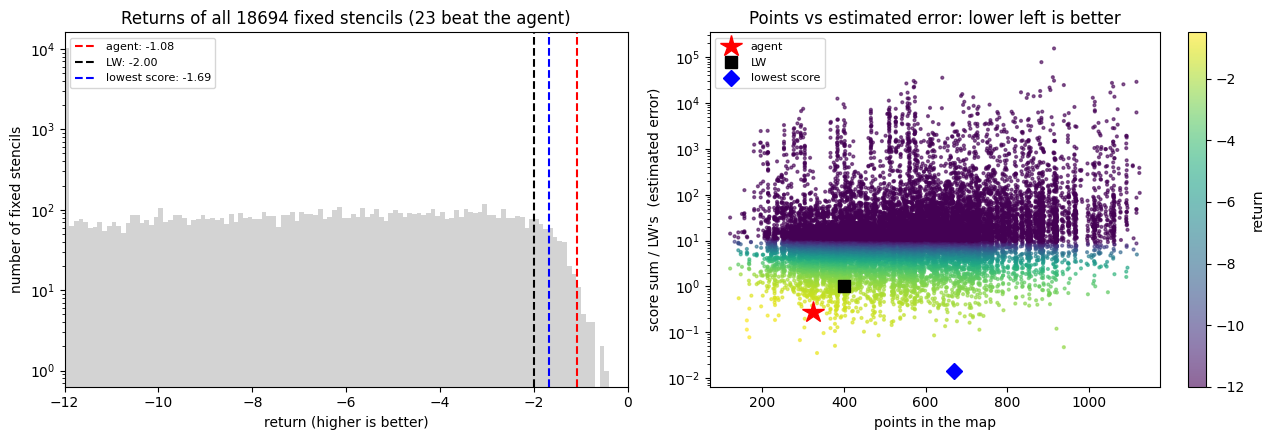

In [22]:
# ── Picture: where the agent sits among all 18,694 fixed stencils ──
B_ref, N_ref = reference(Z_CMP)
R = np.array([r[1] for r in rows]); N = np.array([r[2] for r in rows])
S = -R - LAM * (N - 1) / N_ref                                   # score sum relative to LW, recovered from the return
others = {"agent": agent.m, "LW": build_map(Z_CMP, lw), "lowest score": build_map(Z_CMP, lowest_score)}
marks = {"agent": ("r*", 16), "LW": ("ks", 9), "lowest score": ("bD", 8)}

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
a1.hist(np.clip(R, -12, 0), bins=np.linspace(-12, 0, 121), color="lightgray")   # returns below -12 piled at -12
for name, mm in others.items():
    a1.axvline(map_return(mm, Z_CMP, LAM), color=marks[name][0][0], ls="--", label=f"{name}: {map_return(mm, Z_CMP, LAM):.2f}")
a1.set_yscale("log"); a1.set_xlim(max(R.min(), -12), 0)
a1.set_xlabel("return (higher is better)"); a1.set_ylabel("number of fixed stencils"); a1.legend(fontsize=8)
a1.set_title(f"Returns of all {len(R)} fixed stencils ({sum(R > agent.ret)} beat the agent)")

sc = a2.scatter(N, S, c=np.maximum(R, -12), s=4, cmap="viridis", alpha=0.6)
fig.colorbar(sc, ax=a2, label="return")
for name, mm in others.items():
    B = sum(abs(mm["beta"][p]) * point_score(p, *mm["stencil"][p]) for p in mm["stencil"])
    a2.plot(len(mm["stencil"]), B / B_ref, marks[name][0], ms=marks[name][1], label=name)
a2.set_yscale("log"); a2.set_xlabel("points in the map"); a2.set_ylabel("score sum / LW's  (estimated error)")
a2.set_title("Points vs estimated error: lower left is better"); a2.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Comparison 2: accuracy vs evaluated points
Every method at the same physical $z^*$. Classical schemes (FD-3, LW, Taylor-5, FD-5+RK4, Crank–Nicolson) are run on grids refined 1–4×, giving one curve each. Map methods (agent, best fixed stencil, lowest score, greedy, random) are run on the base grid, one point each: filled marker = true error, open circle = exact bound $\sum|\beta\delta|$.
**Evaluated points** = grid values actually computed in $z^*$'s dependency cone (RK4: ×4 for its 4 stages; Crank–Nicolson: the whole row at every step, since it is implicit).
**Taylor-5** is our own predictor with all 5 Taylor rows (5 points one level down, the heat polynomials $T_1$–$T_4$ cancelled), i.e. a 4th-order scheme.

FD-3        :    400 pts 5.2e-05 |   6400 pts 1.3e-05 |  31374 pts 5.8e-06 |  87390 pts 3.2e-06
LW          :    400 pts 3.0e-05 |   6400 pts 7.5e-06 |  31374 pts 3.3e-06 |  87390 pts 1.9e-06
Taylor-5    :    780 pts 3.3e-08 |  10859 pts 2.4e-08 |  42253 pts 1.2e-10 | 106796 pts 2.3e-08
FD-5 + RK4  :   6468 pts 3.8e-08 |  57840 pts 2.4e-08 | 201644 pts 1.8e-10 | 485400 pts 2.3e-08
CN          :    490 pts 1.8e-05 |   3940 pts 4.4e-06 |  13320 pts 2.0e-06 |  31600 pts 1.1e-06
agent (PPO)       :   323 pts | error 8.2e-08 | exact bound 4.2e-06
best fixed stencil:   168 pts | error 8.4e-07 | exact bound 1.1e-06
lowest score      :   670 pts | error 1.5e-07 | exact bound 1.6e-07
greedy            :   313 pts | error 1.3e-07 | exact bound 4.6e-06
random            :   659 pts | error 7.8e-05 | exact bound 6.5e-04


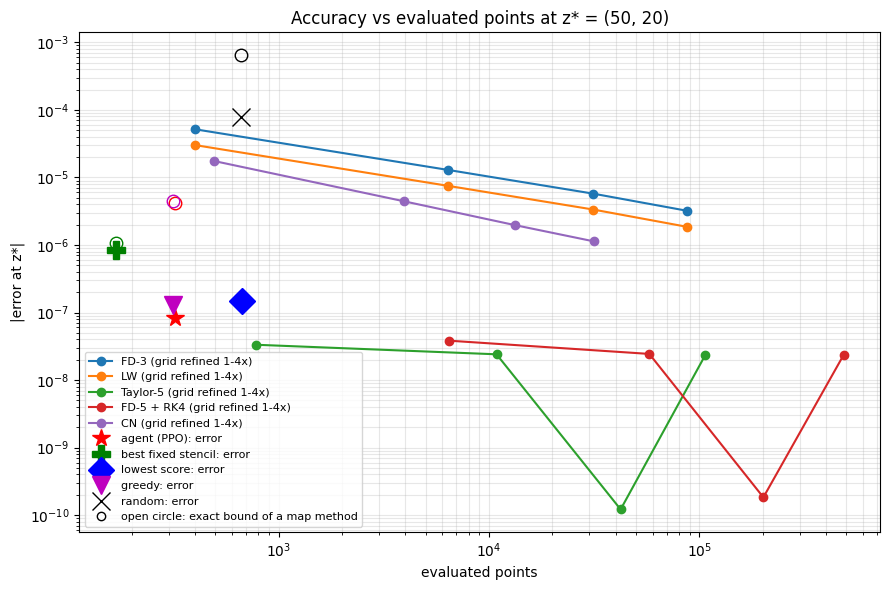

In [23]:
# ── Accuracy vs evaluated points: every method on one plot ──
# Classical schemes run on their own grids (refined by k = 1..4, r = alpha dt/dx^2 kept fixed), so each gives a curve.
# Map methods run on the base grid, so each gives one point. All are measured at the same physical z* = (x*, t*).
from scipy.linalg import solve_banded

x_star, t_star = Z_CMP[0] * dx, Z_CMP[1] * dt

def classical(scheme, k):
    """Error at z* and evaluated points (grid values in z*'s dependency cone) on the grid refined k times."""
    n, h = (nx - 1) * k + 1, dx / k
    tau = dt / k**2 if scheme != "CN" else 4 * dt / k**2            # CN is implicit: 4x bigger steps
    ix, steps = Z_CMP[0] * k, round(t_star / tau)
    x = np.arange(n) * h
    u = u_true(x, 0.0)
    r, nu = alpha * tau / h**2, c * tau / h
    d2 = lambda v: np.r_[0, v[2:] - 2 * v[1:-1] + v[:-2], 0]
    d1 = lambda v: np.r_[0, v[2:] - v[:-2], 0] / 2
    def d4(v):                                                      # 4th-order u_xx*h^2 and u_x*h, 2nd order next to the walls
        a2, a1 = d2(v), d1(v)
        a2[2:-2] = (-v[4:] + 16 * v[3:-1] - 30 * v[2:-2] + 16 * v[1:-3] - v[:-4]) / 12
        a1[2:-2] = (-v[4:] + 8 * v[3:-1] - 8 * v[1:-3] + v[:-4]) / 12
        return a2, a1
    if scheme == "Taylor-5":                                       # weights cancel the heat polynomials T1..T4 exactly
        xi, ta = np.arange(-2, 3) * h + c * tau, -tau * np.ones(5)
        A = np.array([np.ones(5), xi, xi**2 + 2 * alpha * ta, xi**3 + 6 * alpha * ta * xi,
                      xi**4 + 12 * alpha * ta * xi**2 + 12 * (alpha * ta)**2])
        W5 = np.linalg.solve(A, [1, 0, 0, 0, 0])
    if scheme == "CN":
        lo, di, up = -r / 2 - nu / 4, 1 + r, -r / 2 + nu / 4        # (I - tau/2 L) u_new = (I + tau/2 L) u
        ab = np.zeros((3, n - 2)); ab[0, 1:], ab[1], ab[2, :-1] = up, di, lo
    for _ in range(steps):
        if scheme == "FD-3":
            u = u + r * d2(u) - nu * d1(u)
        elif scheme == "LW":
            u = u + (r + nu**2 / 2) * d2(u) - nu * d1(u)
        elif scheme == "FD-5 + RK4":
            f = lambda v: (lambda a2, a1: r * a2 - nu * a1)(*d4(v))
            k1 = f(u); k2 = f(u + k1 / 2); k3 = f(u + k2 / 2); k4 = f(u + k3)
            u = u + (k1 + 2 * k2 + 2 * k3 + k4) / 6
        elif scheme == "Taylor-5":                                  # 5 points one level down, all 5 Taylor rows
            v = u + (r + nu**2 / 2) * d2(u) - nu * d1(u)            # LW next to the walls
            v[2:-2] = W5 @ np.array([u[:-4], u[1:-3], u[2:-2], u[3:-1], u[4:]])
            u = v
        elif scheme == "CN":
            u = np.r_[0, solve_banded((1, 1), ab, (u + r / 2 * d2(u) - nu / 2 * d1(u))[1:-1]), 0]
        u[0] = u[-1] = 0.0
    err = abs(u[ix] - u_true(x_star, t_star)[0])
    spread = {"FD-3": 1, "LW": 1, "Taylor-5": 2, "FD-5 + RK4": 8}.get(scheme)   # cone half-width growth per step
    if spread is None:                                              # CN couples the whole row at every step
        pts = (n - 2) * steps
    else:
        pts = sum(min(n - 2, ix + spread * j) - max(1, ix - spread * j) + 1 for j in range(steps))
        if scheme == "FD-5 + RK4":
            pts *= 4                                                # 4 stage evaluations per point and step
    return pts, err

curves = {s: np.array([classical(s, k) for k in (1, 2, 3, 4)]) for s in ["FD-3", "LW", "Taylor-5", "FD-5 + RK4", "CN"]}

# map methods on the base grid: (points, true error, exact bound)
def greedy(m, p):
    B_ref, N_ref = reference(m["z_star"])
    sets, _, sc = admissible(p)
    cost = [abs(m["beta"][p]) * s_ / B_ref
            + LAM * sum(1 for q in {place(p, k) for k in st} if not is_known(q) and q not in m["beta"]) / N_ref
            for st, s_ in zip(sets, sc)]
    return [place(p, k) for k in sets[int(np.argmin(cost))]]

maps = {"agent (PPO)": agent.m, "best fixed stencil": build_map(Z_CMP, fixed_rule(rows[0][0])),
        "lowest score": build_map(Z_CMP, lowest_score), "greedy": build_map(Z_CMP, greedy),
        "random": None}
rnd = MapEnv([Z_CMP], lam=LAM); rnd.reset(seed=0); rng, done = np.random.default_rng(0), False
while not done:
    _, _, done, _, _ = rnd.step(rng.choice(np.flatnonzero(rnd.action_masks())))
maps["random"] = rnd.m
pts_map = {name: report(mm) for name, mm in maps.items()}

for s, cv in curves.items():
    print(f"{s:12s}: " + " | ".join(f"{int(p):6d} pts {e:.1e}" for p, e in cv))
for name, rep in pts_map.items():
    print(f"{name:18s}: {rep['points']:5d} pts | error {rep['error']:.1e} | exact bound {rep['bound']:.1e}")

fig, ax = plt.subplots(figsize=(9, 6))
for i, (s, cv) in enumerate(curves.items()):
    ax.loglog(cv[:, 0], cv[:, 1], "o-", color=f"C{i}", label=f"{s} (grid refined 1-4x)")
marks = {"agent (PPO)": "r*", "best fixed stencil": "gP", "lowest score": "bD", "greedy": "mv", "random": "kx"}
for name, rep in pts_map.items():
    ax.loglog(rep["points"], rep["error"], marks[name], ms=13, label=f"{name}: error")
    ax.loglog(rep["points"], rep["bound"], marks[name][0] + "o", ms=9, mfc="none")
ax.plot([], [], "ko", mfc="none", label="open circle: exact bound of a map method")
ax.set_xlabel("evaluated points"); ax.set_ylabel("|error at z*|")
ax.set_title(f"Accuracy vs evaluated points at z* = {Z_CMP}"); ax.legend(fontsize=8); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

### Multi-query training: does one agent generalise?
One agent trained on 15 queries ($t^*\in\{10,\dots,30\}$, $x^*\in\{30,50,70\}$), later tested on queries it has never seen.
Two state fixes so that the state means the same thing at every query:
- *levels above the IC* is clipped at 10 (only "is the IC within reach" matters, and longer $t^*$ stays in range);
- *offset to $z^*$* is replaced by the *distance to the nearest wall*, clipped at 10 (the walls matter physically, the position of $z^*$ does not).

In [40]:
# ── Updated helpers: same as cell 9, plus a choice of environment class ──
def make_env(queries, lam, seed, env_cls=MapEnv):
    def _init():
        env = Monitor(ActionMasker(env_cls(queries=queries, lam=lam), lambda e: e.action_masks()))
        env.reset(seed=seed)
        return env
    return _init

def run_policy(model, z, lam, env_cls=MapEnv):
    """One episode on z* with the policy's most likely picks. Returns the finished env (map in env.m)."""
    env = env_cls(queries=[z], lam=lam)
    obs, _ = env.reset(seed=0)
    done, ret = False, 0.0
    while not done:
        a, _ = model.predict(obs, action_masks=env.action_masks(), deterministic=True)
        obs, r, done, _, info = env.step(a)
        ret += r
    env.ret, env.info = ret, info
    return env

class SnapshotCallback(BaseCallback):
    def __init__(self, z_plot, lam, every, img_dir, env_cls=MapEnv):
        super().__init__()
        self.z_plot, self.lam, self.every, self.img_dir, self.env_cls = z_plot, lam, every, img_dir, env_cls
        self.last, self.hist, self.episodes = -every, [], 0

    def _on_step(self):
        self.episodes += sum("episode" in info for info in self.locals["infos"])   # maps finished in training
        if self.num_timesteps - self.last >= self.every:
            self.last = self.num_timesteps
            env = run_policy(self.model, self.z_plot, self.lam, self.env_cls)
            if env.info["finished"]:
                rep = report(env.m)
                plot_map(env.m, f"step {self.num_timesteps:,}  ({self.episodes} maps)  |  return {env.ret:.2f}",
                         os.path.join(self.img_dir, f"map_{self.num_timesteps:09d}.png"))
            else:
                rep = {"points": env.info["points"], "work": np.nan, "error": np.nan, "bound": np.nan}
            self.hist.append({"step": self.num_timesteps, "episodes": self.episodes, "return": env.ret, **rep})
            print(f"step {self.num_timesteps:>10,} | {self.episodes:5d} maps: return {env.ret:7.2f} | "
                  f"{rep['points']} points | bound {rep['bound']:.1e} | finished {env.info['finished']}")
        return True

In [41]:
import json, time
from stable_baselines3.common.callbacks import CheckpointCallback
N_ENVS = 12
PPO_KW_MQ = dict(n_steps=1024, batch_size=2048, gamma=1.0, gae_lambda=0.98, learning_rate=3e-4, ent_coef=0.0)

# ── Environment for many queries: same as MapEnv, with two state entries made query-independent ──
class MapEnvGen(MapEnv):
    def _obs(self):
        o = super()._obs()
        if self.m["pending"]:
            p = next_point(self.m)
            o[4 * N_CELLS + 1] = min(p[1], 10)                        # levels above the IC, clipped
            o[4 * N_CELLS + 2] = min(p[0], nx - 1 - p[0], 10)         # distance to the nearest wall, clipped
        return o

# ── Settings ──
TRAIN_Q   = [(50, t) for t in (10, 20, 30, 40, 50)]
TOTAL_MQ  = 20_000_000
Z_PLOT_MQ = (50, 20)
LAM_MQ    = 1.0
SEED_MQ   = 1
SNAP_EVERY, CKPT_EVERY = 500_000, 1_000_000

run_dir_mq = os.path.join(f"runs{date.today().month}-{date.today().day}", f"multi15_gae098_n1024_lam{LAM_MQ:g}_R{R_X}K{K_T}")
seed_dir   = os.path.join(run_dir_mq, f"seed{SEED_MQ}")
img_dir, ckpt_dir = os.path.join(seed_dir, "images"), os.path.join(seed_dir, "checkpoints")
os.makedirs(img_dir, exist_ok=True); os.makedirs(ckpt_dir, exist_ok=True)
with open(os.path.join(run_dir_mq, "config.json"), "w") as f:
    json.dump(dict(queries=TRAIN_Q, z_plot=Z_PLOT_MQ, lam=LAM_MQ, seed=SEED_MQ, total=TOTAL_MQ, n_envs=N_ENVS,
                   env="MapEnvGen (levels clipped at 10, distance to wall clipped at 10)",
                   window=dict(R_X=R_X, K_T=K_T, N_NB=N_NB), ppo=PPO_KW_MQ, date=str(date.today())), f, indent=2)
print("run folder:", run_dir_mq)

# fill the caches once (reference maps, admissible stencils near the walls and the IC); workers get a copy
t0 = time.time()
for z in TRAIN_Q:
    reference(z); build_map(z, lowest_score)
print(f"caches filled for {len(TRAIN_Q)} queries in {time.time() - t0:.0f} s")

# ── Train ──
vec = SubprocVecEnv([make_env(TRAIN_Q, LAM_MQ, seed=100 * SEED_MQ + i, env_cls=MapEnvGen) for i in range(N_ENVS)])
model_mq = MaskablePPO("MlpPolicy", vec, seed=SEED_MQ, verbose=0, device="cpu",
                       tensorboard_log=os.path.join(seed_dir, "logs"), **PPO_KW_MQ)
snap_mq = SnapshotCallback(Z_PLOT_MQ, LAM_MQ, every=SNAP_EVERY, img_dir=img_dir, env_cls=MapEnvGen)
t0 = time.time()
model_mq.learn(total_timesteps=TOTAL_MQ, tb_log_name="ppo",
               callback=[MapLogCallback(), snap_mq,
                         CheckpointCallback(save_freq=max(CKPT_EVERY // N_ENVS, 1), save_path=ckpt_dir, name_prefix="ppo")])
vec.close()
print(f"training time: {(time.time() - t0) / 60:.0f} min")

model_mq.save(os.path.join(ckpt_dir, "ppo_final"))
with open(os.path.join(seed_dir, "snapshots.json"), "w") as f:
    json.dump(snap_mq.hist, f, indent=1, default=float)
env_mq = run_policy(model_mq, Z_PLOT_MQ, LAM_MQ, MapEnvGen)
plot_map(env_mq.m, f"multi-query agent, final  |  return {env_mq.ret:.2f}", os.path.join(img_dir, "map_final.png"))
print("final at", Z_PLOT_MQ, ":", {k: (f"{v:.2e}" if isinstance(v, float) else v) for k, v in report(env_mq.m).items()},
      f"| return {env_mq.ret:.2f}")

run folder: runs10-7\multi15_gae098_n1024_lam1_R3K3
caches filled for 5 queries in 0 s
step         12 |     0 maps: return  -35.53 | 532 points | bound 1.4e-03 | finished True
step    500,016 |    56 maps: return   -2.14 | 387 points | bound 4.3e-05 | finished True
step  1,000,020 |   142 maps: return   -2.28 | 359 points | bound 4.2e-05 | finished True
step  1,500,024 |   231 maps: return   -1.81 | 368 points | bound 1.9e-05 | finished True
step  2,000,028 |   318 maps: return   -1.76 | 369 points | bound 1.7e-05 | finished True
step  2,500,032 |   400 maps: return   -1.69 | 370 points | bound 1.4e-05 | finished True
step  3,000,036 |   472 maps: return   -1.80 | 413 points | bound 1.4e-05 | finished True
step  3,500,040 |   547 maps: return   -1.80 | 413 points | bound 1.4e-05 | finished True
step  4,000,044 |   625 maps: return   -1.81 | 420 points | bound 1.4e-05 | finished True
step  4,500,048 |   705 maps: return   -1.85 | 438 points | bound 1.3e-05 | finished True
step  5,000,0